In [1]:
!wget -nc https://storage.googleapis.com/tensorflow-1-public/course3/imdb_vocab_subwords.txt

--2026-05-03 17:03:34--  https://storage.googleapis.com/tensorflow-1-public/course3/imdb_vocab_subwords.txt
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.118.207, 74.125.200.207, 74.125.130.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.118.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53151 (52K) [text/plain]
Saving to: ‘imdb_vocab_subwords.txt’

imdb_vocab_subwords 100%[===================>]  51.91K  --.-KB/s    in 0.04s   

2026-05-03 17:03:36 (1.13 MB/s) - ‘imdb_vocab_subwords.txt’ saved [53151/53151]



In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras_nlp

In [3]:
imdb = tfds.load('imdb_reviews', as_supervised=True, data_dir="./data")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.ZAX2J6_1.0.0/imdb_reviews-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.ZAX2J6_1.0.0/imdb_reviews-test.tfrecord*...:   0%|          …

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling data/imdb_reviews/plain_text/incomplete.ZAX2J6_1.0.0/imdb_reviews-unsupervised.tfrecord*...:   0%|  …

Dataset imdb_reviews downloaded and prepared to data/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [4]:
train_reviews = imdb['train'].map(lambda review, label: review)
test_reviews = imdb['test'].map(lambda review, label : review)

train_labels = imdb['train'].map(lambda review, label : label)
test_labels = imdb['test'].map(lambda review, label : label)

In [5]:
subword_tokenizer = keras_nlp.tokenizers.WordPieceTokenizer(vocabulary="./imdb_vocab_subwords.txt")

In [6]:
SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 256
PADDING_TYPE = "pre"
TRUNC_TYPE = "post"

In [7]:
def padding_function(sequences):
  sequences = sequences.ragged_batch(batch_size = sequences.cardinality())
  sequences = sequences.get_single_element()
  padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(), padding=PADDING_TYPE, truncating=TRUNC_TYPE)
  padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)
  return padded_sequences

In [8]:
train_sequences_subword = train_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_function)

In [9]:
test_sequence_subword = test_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_function)

In [10]:
train_data_vect = tf.data.Dataset.zip(train_sequences_subword, train_labels)
test_data_vect = tf.data.Dataset.zip(test_sequence_subword, test_labels)

In [11]:
test_data_vect = test_data_vect.batch(BATCH_SIZE).prefetch(PREFETCH_BUFFER_SIZE)
train_data_vect = train_data_vect.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(PREFETCH_BUFFER_SIZE)

In [12]:
# Parameters
BATCH_SIZE = 1
TIMESTEPS = 20
FEATURES = 16
LSTM_DIM = 8
import numpy as np
print(f'batch_size: {BATCH_SIZE}')
print(f'timesteps (sequence length): {TIMESTEPS}')
print(f'features (embedding size): {FEATURES}')
print(f'lstm output units: {LSTM_DIM}')

# Define array input with random values
random_input = np.random.rand(BATCH_SIZE,TIMESTEPS,FEATURES)
print(f'shape of input array: {random_input.shape}')

# Define LSTM that returns a single output
lstm = tf.keras.layers.LSTM(LSTM_DIM)
result = lstm(random_input)
print(f'shape of lstm output(return_sequences=False): {result.shape}')

# Define LSTM that returns a sequence
lstm_rs = tf.keras.layers.LSTM(LSTM_DIM, return_sequences=True)
result = lstm_rs(random_input)
print(f'shape of lstm output(return_sequences=True): {result.shape}')

batch_size: 1
timesteps (sequence length): 20
features (embedding size): 16
lstm output units: 8
shape of input array: (1, 20, 16)
shape of lstm output(return_sequences=False): (1, 8)
shape of lstm output(return_sequences=True): (1, 20, 8)


In [13]:
EMBEDDING_DIM = 64
LSTM1_DIM = 32
LSTM2_DIM = 16
DENSE_DIM = 64

model = tf.keras.Sequential([
    tf.keras.Input(shape=(None,)),
    tf.keras.layers.Embedding(input_dim=subword_tokenizer.vocabulary_size(), output_dim=EMBEDDING_DIM),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM1_DIM, return_sequences = True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM2_DIM)),
    tf.keras.layers.Dense(DENSE_DIM, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       488,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 64)       │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,017 (2.01 MB)

 Trainable params: 526,017 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
epoches = 5
history = model.fit(train_data_vect, epochs=epoches, validation_data=test_data_vect)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 91s 862ms/step - accuracy: 0.7307 - loss: 0.5161 - val_accuracy: 0.8290 - val_loss: 0.3893
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 75s 766ms/step - accuracy: 0.8845 - loss: 0.2909 - val_accuracy: 0.8653 - val_loss: 0.3224
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 77s 785ms/step - accuracy: 0.9204 - loss: 0.2164 - val_accuracy: 0.8619 - val_loss: 0.3942
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 770ms/step - accuracy: 0.9007 - loss: 0.2503 - val_accuracy: 0.8395 - val_loss: 0.3702
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 773ms/step - accuracy: 0.9484 - loss: 0.1456 - val_accuracy: 0.8394 - val_loss: 0.4248


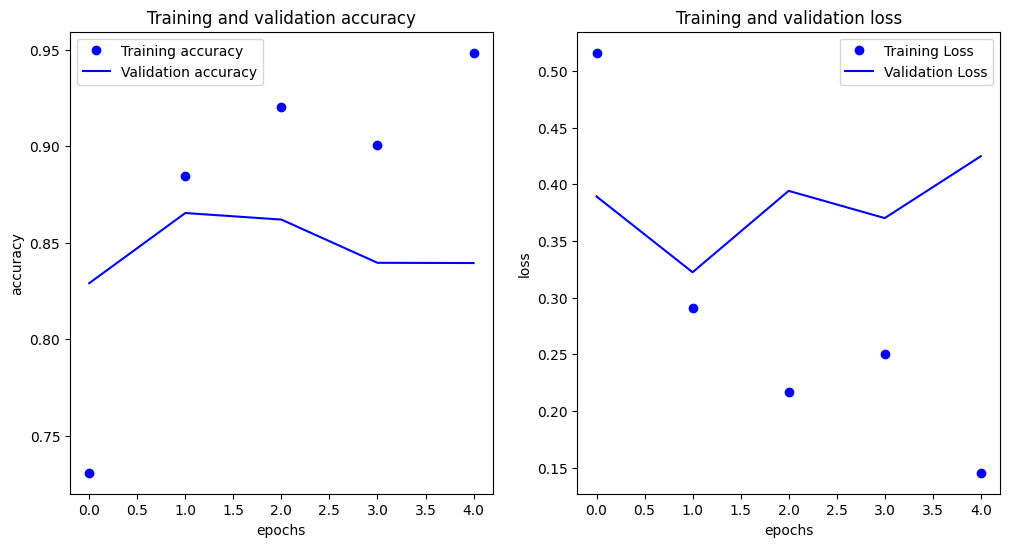

In [16]:
def plot_loss_acc(history):
  '''Plots the training and validation loss and accuracy from a history object'''
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  fig, ax = plt.subplots(1,2, figsize=(12, 6))
  ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
  ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
  ax[0].set_title('Training and validation accuracy')
  ax[0].set_xlabel('epochs')
  ax[0].set_ylabel('accuracy')
  ax[0].legend()

  ax[1].plot(epochs, loss, 'bo', label='Training Loss')
  ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
  ax[1].set_title('Training and validation loss')
  ax[1].set_xlabel('epochs')
  ax[1].set_ylabel('loss')
  ax[1].legend()

  plt.show()

plot_loss_acc(history)

In [17]:
# Shutdown the kernel to free up resources.
# Note: You can expect a pop-up when you run this cell. You can safely ignore that and just press `Ok`.

from IPython import get_ipython

k = get_ipython().kernel

k.do_shutdown(restart=False)

{'status': 'ok', 'restart': False}